In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk

In [2]:
from google.colab import files
uploaded = files.upload()

Saving SMSSpamCollection to SMSSpamCollection


In [3]:
import os

print(os.listdir('/content'))

['.config', 'SMSSpamCollection', 'sample_data']


In [4]:
import pandas as pd

df = pd.read_csv(
    '/content/SMSSpamCollection',
    sep='\t',
    names=['label', 'message']
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print(df.shape)
print(df.head())

(5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [6]:
print(df.info())
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label
ham     4825
spam     747
Name: count, dtype: int64


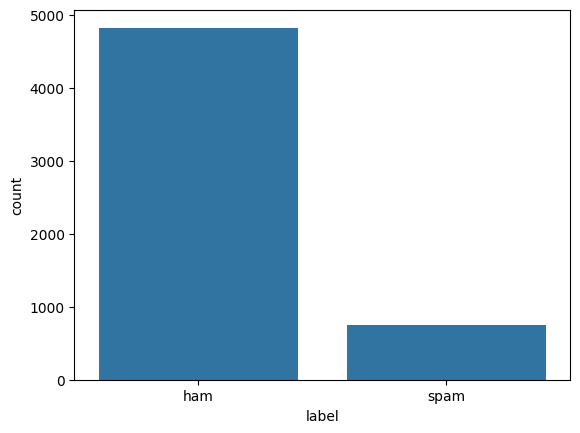

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.show()

In [8]:
import nltk
nltk.download('stopwords')

import string
from nltk.corpus import stopwords

def preprocess(text):

    text = text.lower()

    text = ''.join(
        c for c in text
        if c not in string.punctuation
    )

    words = text.split()

    words = [
        word for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
import os
print(os.listdir('/content'))

['.config', 'SMSSpamCollection', 'sample_data']


In [10]:
print(df.shape)
print(df.head())

(5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [11]:
import nltk
import string

from nltk.corpus import stopwords

def preprocess(text):
    text = str(text).lower()

    text = ''.join(
        c for c in text
        if c not in string.punctuation
    )

    words = text.split()

    words = [
        word for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

df['processed_message'] = df['message'].apply(preprocess)

df[['message', 'processed_message']].head()

,message,processed_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df['processed_message']
)

In [13]:
y = df['label'].map({
    'ham':0,
    'spam':1
})

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9542600896860987


In [18]:
from sklearn.metrics import precision_score

print(
    precision_score(
        y_test,
        y_pred
    )
)

0.9711538461538461


In [19]:
from sklearn.metrics import f1_score

print(
    f1_score(
        y_test,
        y_pred
    )
)

0.7984189723320159


In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[963   3]
 [ 48 101]]


In [21]:
msg = """
Congratulations!
You have won ₹50,000.
Click here to claim.
"""

processed = preprocess(msg)

vector = vectorizer.transform([processed])

prediction = model.predict(vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Ham


In [22]:
import pickle

pickle.dump(
    model,
    open("spam_model.pkl","wb")
)

pickle.dump(
    vectorizer,
    open("vectorizer.pkl","wb")
)

In [23]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 93.5 MB/s eta 0:00:00


In [24]:
import streamlit as st
import pickle

model = pickle.load(
    open("spam_model.pkl","rb")
)

vectorizer = pickle.load(
    open("vectorizer.pkl","rb")
)

st.title("Spam Mail Detector")

message = st.text_area(
    "Enter Email Text"
)

if st.button("Predict"):

    vector = vectorizer.transform(
        [message]
    )

    prediction = model.predict(vector)

    if prediction[0] == 1:
        st.error("Spam Email")
    else:
        st.success("Not Spam")

2026-06-04 10:29:24.952 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:29:26.212 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-04 10:29:26.221 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:29:26.225 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:29:26.230 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:29:26.236 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:29:26.240 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:29:26.244 Thread 'MainThread': mi

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['processed_message'])

y = df['label'].map({
    'ham': 0,
    'spam': 1
})

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [28]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9704035874439462


In [29]:
import pickle

pickle.dump(model, open("spam_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [30]:
msg = "Congratulations! You have won a free iPhone. Click now."

processed = preprocess(msg)

vector = vectorizer.transform([processed])

prediction = model.predict(vector)

print("Spam" if prediction[0] == 1 else "Ham")

Ham


In [31]:
msg = "FREE entry into our prize draw. Claim your reward now!"

processed = preprocess(msg)

vector = vectorizer.transform([processed])

prediction = model.predict(vector)

print("Spam" if prediction[0] == 1 else "Ham")

Spam


In [32]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9704035874439462
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [33]:
import pickle

pickle.dump(model, open("spam_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [34]:
import os
print(os.listdir())

['.config', 'spam_model.pkl', 'vectorizer.pkl', 'SMSSpamCollection', 'sample_data']


In [35]:
import pickle

pickle.dump(model, open("spam_model.pkl", "wb"))

In [36]:
import os
print(os.listdir('/content'))

['.config', 'spam_model.pkl', 'vectorizer.pkl', 'SMSSpamCollection', 'sample_data']


In [37]:
from google.colab import files
files.download("spam_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [39]:
from google.colab import files
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>